# Lecture 12

## Convolutional neural networks using Pytorch

For image data, including medical images, convolutional neural networks are widely used. In this class, we will cover:
- the basics of convolutional neural networks and how to implement them in PyTorch
- how to load a pretrained network and use it on your own data


This will also be a good opportunity to learn about debugging in VS Code.

Convolutional neural networks consist of four main types of operations:

- Convolutions: these apply small learnable filters, or kernels, across the image to detect local patterns such as edges, textures, and shapes
- Pooling: this reduces the size of the image
learn higher level features, reduce image by half, identify squares 2 x 2 and identify maximum element in each square and reduce image to the largest pixel 
keep repeating convulution and pooling until you end up with image that is very small 
- Nonlinear activation functions: these introduce nonlinearity into the network. A common choice is the ReLU activation function.
- Fully connected layers: these combine the extracted features and map them to the final output

replace some of those layers with layers with operations more natural for images
those layers are called convultion 

<div style="text-align: center;">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20260217113409515144/working_of_cnn__.webp" width="600">
</div>

not to vectorize an image, instead look at it like an image if you vectorize it you dont recognize the image anymore or structure of it 

convulution - identify a square and do an operation within that image 
do an average within that square and move the square around so you keep repeating operation until you repeat the image until its the original size 

can have a smooth image depending on the filter you use 

bridge neural network world with image processing world 

final output is a prediction based on the image you see 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision

First, download MedNIST data.

In [3]:
from medmnist import PneumoniaMNIST

#had to create a folder named data 

train_ds = PneumoniaMNIST(split="train", download=True, root='data')
test_ds = PneumoniaMNIST(split="test", download=True, root='data')

print(train_ds)

Dataset PneumoniaMNIST of size 28 (pneumoniamnist)
    Number of datapoints: 4708
    Root location: data
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'normal', '1': 'pneumonia'}
    Number of samples: {'train': 4708, 'val': 524, 'test': 624}
    Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
    License: CC BY 4.0


In [4]:
print(train_ds.imgs.shape)
print(test_ds.imgs.shape)

label_names = train_ds.labels
label_names # tells us if each subject has pneumonia or not (0 or 1)

#takes a long time to get the images to this place 

#28 x 28 images 
# 4708 subjects in train
# 624 subjects in test

(4708, 28, 28)
(624, 28, 28)


array([[1],
       [1],
       [1],
       ...,
       [1],
       [0],
       [1]], shape=(4708, 1), dtype=uint8)

In [5]:
batch_size = 128 # how many observations at time should be passed through the model at a time


transform = torchvision.transforms.ToTensor()
train_X = torch.stack([transform(x) for x in #each image transform into a tensor then stack images into a big tensor with number of subjects by 28 x 28 
                            train_ds.imgs])
test_X = torch.stack([transform(x) for x in
                            test_ds.imgs])
train_tns = TensorDataset(train_X,
                            torch.tensor(train_ds.labels, dtype=torch.float)) # add tensor of labels to the tensor dataset, convert labels to float for binary classification
test_tns = TensorDataset(test_X,
                            torch.tensor(test_ds.labels, dtype=torch.float)) # do the same for test data set 

train_loader = DataLoader(train_tns, batch_size=batch_size)  #data loader is the object that will allow us to easily access the data 
test_loader = DataLoader(test_tns, batch_size=1000) # this is for testing for large images may be reduced to 1 

# note that torch requires image tensors to be ... [N, C, H, W] 
# N: number of samples, C: number of channels, H: height, W: width

#torch allows us to work with images 
#need to conver to pytorch tensors and then create a dataloader object that will allow us to easily access the data in batches
# torchvision.transforms only preprocessing to do is to convert the images to tensors, which we can do with torchvision.transforms.ToTensor() function. 
# This will convert the images to PyTorch tensors and also scale the pixel values to be between 0 and 1.

In [6]:
train_X.shape 

# this is the shape of the training data tensor, should be [4708, 1, 28, 28] where 4708 is the number of subjects, 1 is the number of channels (grayscale), and 28 x 28 is the height and width of the images.

torch.Size([4708, 1, 28, 28])

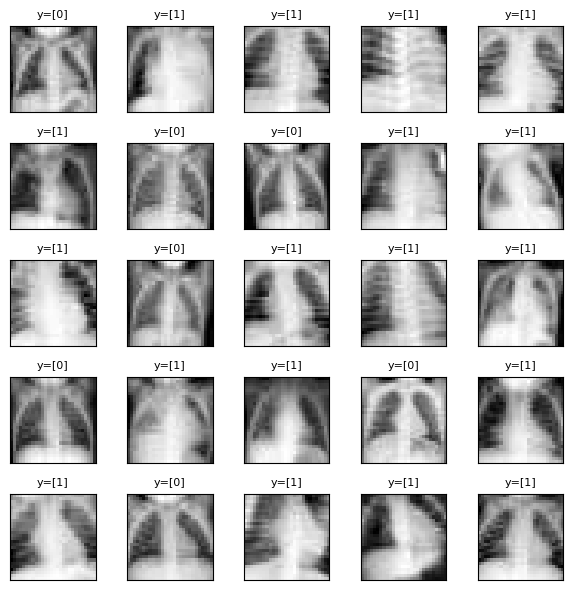

In [7]:
#take a few images and make a 5 x 5 grid of images with the labels as titles

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
rng = np.random.default_rng(4)
indices = rng.choice(np.arange(len(train_tns)), 25,
                     replace=False).reshape((5, 5))

for i in range(5):
    for j in range(5):
        idx = indices[i, j]
        axes[i, j].imshow(
            train_X[idx][0],
            cmap="gray",
            interpolation=None
        )
        axes[i, j].set_title(f"y={train_ds.labels[idx]}", fontsize=8)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()

In [8]:
conv_layer = nn.Conv2d(in_channels=1,  #number of input channels (1 for grayscale, 3 for RGB),
                              out_channels=1, #number of output channels (number of filters in the convolutional layer)
                              kernel_size=(3,3), #size of the filter (3 x 3)
                              padding='same') # images tend to be slightler smaller after convolution, 
                                # padding='same' will add zeros around the edges of the image to keep the same size after convolution

#filter is a 3 x 3 matrix that will be convolved with the input image to produce an output image.
#nn Conv2d is a convolutional layer that takes in a 4D tensor of shape [N, C, H, W] and produces a 4D tensor of shape [N, out_channels, H, W]
#  where out_channels is the number of filters in the convolutional layer.
print(conv_layer.bias)

#shift that applies to overall image 
print(conv_layer.weight)

#3x3 kernel that this filter applies to images 

Parameter containing:
tensor([-0.1647], requires_grad=True)
Parameter containing:
tensor([[[[ 0.2376, -0.2028, -0.2304],
          [ 0.2623, -0.0116, -0.0829],
          [ 0.3175, -0.0973,  0.0577]]]], requires_grad=True)


In [9]:
kernel = torch.tensor([
    [[[-1., -1., -1.],
      [-1.,  8., -1.],
      [-1., -1., -1.]]]
])  # shape [1, 1, 3, 3]
# #highlights edges in the image, this is called a Laplacian filter

# kernel = torch.tensor([
#     [[[1., 2., 1.],
#       [2., 4., 2.],
#       [1., 2., 1.]]]
# ], dtype=torch.float32) / 16

with torch.no_grad(): #not training model, just playing around
    conv_layer.weight.copy_(kernel)
    conv_layer.bias.copy_(torch.tensor([0]))



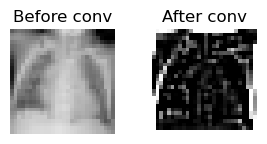

In [10]:
#apply filter to image 
x = train_X[0][0]          # shape: [H, W]
x_in = x.unsqueeze(0).unsqueeze(0)  # shape: [1, 1, H, W] #makes it into a 4 dimensional array 

#x for plotting and x_in for applying convolution, they are the same image just different shapes

# apply convolution
y = conv_layer(x_in)                # shape: [1, C_out, H_out, W_out]

# plot input and first output channel
fig, axes = plt.subplots(1, 2, figsize=(3, 1.5))

axes[0].imshow(x.cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Before conv")
axes[0].axis("off")

axes[1].imshow(y[0, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("After conv")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#input image and output image after applying the convolutional filter, 
# we can see that the edges of the image are highlighted in the output image.


Let's set up our convolutional neural network.

In [11]:
class BuildingBlock(nn.Module): 

    def __init__(self,
                 in_channels,   #gives the option to change parameters of the convultional layer, this is the number of channels in the input image
                 out_channels):
        super(BuildingBlock, self).__init__()

        self.conv = nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels,
                              kernel_size=(3,3),
                              padding='same')
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2,2))
        #reduces the size of the image by a factor of 2, this is called downsampling
        #reduces to 1 x 1 image, this is called global average pooling, this is often used at the end of a convolutional neural
        #  network to reduce the size of the image to a single value per channel, which can then be fed into a fully connected layer for classification.

    def forward(self, x): #take input image and apply convolution, activation, and pooling to it
        x_out = self.conv(x)
        x_out = self.activation(x_out) # applies the ReLU activation function to the output of the convolutional layer, 
        # which sets all negative values to 0 and keeps all positive values unchanged. This introduces non-linearity into the model, allowing it to learn more complex patterns in the data.
        x_out = self.pool(x_out) #reduces the size of the image by a factor of 2, this is called downsampling
        return x_out

class ConvModel(nn.Module): #uses building block to create more complicated 


    def __init__(self):
        super(ConvModel, self).__init__()

        self.conv1 = BuildingBlock(1, 32) #one input channel (grayscale) and 32 output channels (filters), one image to several images with different filters 
        self.conv2 = BuildingBlock(32, 64) 

        self.output = nn.Sequential( #apply sequentially 
            nn.Dropout(0.5),
            nn.Linear(7 * 7 * 64, 100), #apply linear layer to the output for
            nn.ReLU(),
            nn.Linear(100, 1)
        )

    def forward(self, x):
        val = self.conv1(x) #apply first convolutional layer to the input image, this will produce 32 output channels (filters) and reduce the size of the image by a factor of 2 (from 28 x 28 to 14 x 14)
        val = self.conv2(val) # apply second convolutional layer to the output of the first convolutional layer, this will produce 64 output channels (filters) and reduce the size of the image by a factor of 2 (from 14 x 14 to 7 x 7)

        val = torch.flatten(val, start_dim=1) #flatten image into a long vector 
        return self.output(val)
    
    #specifies what this model does 


Let's instantiate our CNN model

In [12]:
model = ConvModel()

In [13]:
y_pred = model(x_in)
print(y_pred)



tensor([[0.0822]], grad_fn=<AddmmBackward0>)


In [15]:
loss_fn = torch.nn.BCEWithLogitsLoss(reduction="sum") # Binary Cross Entropy loss, checks how far your predictions are from true values


lr = 0.001 #specify learning rate
epochs = 100 #specify number of epochs to train for, one epoch is one pass through the entire training data set

optimizer = optim.Adam(model.parameters(), lr=lr)

# set model to training mode
model.train()

for epoch in range(epochs):
    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)

        loss.backward()  
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

    if epoch % 10 == 0:
        print('epoch: ', epoch, 'loss:', f"{epoch_loss:.3}")


epoch:  0 loss: 8.74e+02
epoch:  10 loss: 6.89e+02
epoch:  20 loss: 5.68e+02
epoch:  30 loss: 4.62e+02
epoch:  40 loss: 3.79e+02
epoch:  50 loss: 3.17e+02
epoch:  60 loss: 1.83e+02
epoch:  70 loss: 1.37e+02
epoch:  80 loss: 92.6
epoch:  90 loss: 76.1


We save the trained model so we can access it later.

In [16]:
filename = 'xray-model.pt'
torch.save(model.state_dict(), filename)

#store the weights into a file 
# every parameter in the neural network it stores the name and its value 

Load model:

In [18]:
model.load_state_dict(torch.load(filename))

#reload the weights so you dont have to retrain the model 
#open weight models 
#gives you the weight value load it into your model 

<All keys matched successfully>

Let's calculate the accuracy of the model on a subset of the data.

In [19]:
model.eval()
x_batch, y_batch = next(iter(train_loader))

with torch.no_grad():
    logits_pred = model(x_batch) # only concerned with accuracy of predictions, not training the model, so we dont need to calculate gradients
    probs_pred = torch.sigmoid(logits_pred) #apply sigmoid to get probabilities from logits
    y_pred = (probs_pred > 0.5).long() #transform into integers, if probability is greater than 0.5, predict 1 (pneumonia), otherwise predict 0 (no pneumonia)
    acc = (y_pred == y_batch.long()).float().mean()

print(acc.item())

#what is the proportion of the predicted labels with the true labels 
#this was done on training data 

1.0


In [20]:
model.eval()
x_batch, y_batch = next(iter(test_loader)) #use test data now with the same code as before 

with torch.no_grad():
    logits_pred = model(x_batch)
    probs_pred = torch.sigmoid(logits_pred)
    y_pred = (probs_pred > 0.5).long()
    acc = (y_pred == y_batch).float().mean()

print(acc.item())

#want to check the test data to make sure the test data has a balance amount of case and controls 

0.879807710647583



Let's look at some examples the model got right and wrong:

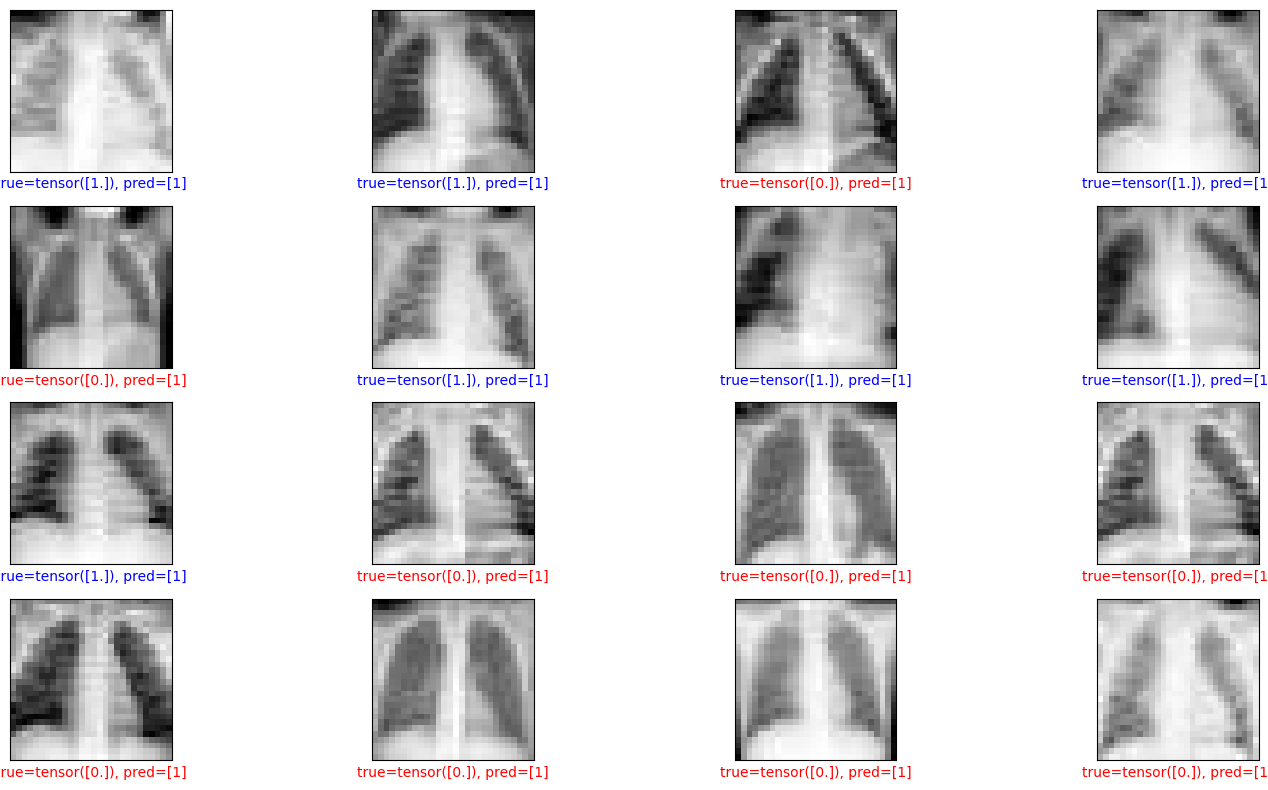

In [21]:
correct =  torch.where(y_pred == y_batch)[0]
errors = torch.where(y_pred != y_batch)[0]
inds1 = np.random.choice(correct.numpy(), size = 8)
inds2 = np.random.choice(errors.numpy(), size = 8)
inds = np.concatenate((inds1, inds2))

pred_array = y_pred.detach().numpy()

num_rows = 4
num_cols = 4
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    n = inds[i]
    plt.subplot(num_rows, num_cols, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image, label = x_batch[n], y_batch[n]

    plt.imshow(np.transpose(image,
                        [1, 2, 0]),
           interpolation=None, cmap="gray")
    plt.xlabel(label)
    predicted_label = label_names[y_pred[n]]
    if predicted_label == label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("true={}, pred={}".format(
        label,
        predicted_label),
        color=color)
    

plt.tight_layout() 

#have domain expert look at the images and see if the model is making mistakes on images that are hard to classify, 
# and if the model is getting the right answers for the right reasons (e.g. is it looking at the right parts of the image to make its predictions).

#what is the golden standard for diagnosing pneumonia, and how does the model's performance compare to that?
#is having a physician look at the images the golden standard, or is it something else like a CT scan or a biopsy? since doctors can get it wrong too 


### ResNet

The `torchvision.models` package provides pre-trained models like ResNet-50 (a ResNet model with 50 layers). (Note this uses code from https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch10-deeplearning-lab.ipynb)

ResNet takes an input image and outputs predicted scores or probabilities for a set of classes.

- **Input:** an image, for example a \(224 \times 224 \times 3\) color image
- **Output:** a vector of class scores, one for each possible category (1000 classes) trained to recognize object in the images
it has to pick which of the classes the object belongs to 

using someone elses neural networks 

### Here we apply ResNet to one or more images of your choice, which you should store in img_examples/

In [23]:
from torchvision.models import (resnet50, ResNet50_Weights)
from torchvision.transforms import (Resize,
                                    Normalize,
                                    CenterCrop,
                                    ToTensor)
from torchvision.io import read_image
from glob import glob
import json
import pandas as pd

In [ ]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)  #weights defined by someone else 

#have a neural network wiht res net 50 weights 

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\lsmix/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:14<00:00, 7.27MB/s]


In [ ]:
resnet_model
#has 50 layers in this example 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [26]:
# We need to normalize the images for use for ResNet-50

resize = Resize((232,330), antialias=True) #have to crop image into the same size as the images that were used to train the resnet model, this is 224 x 224, 
#but we will crop it to 224 x 224 after resizing it to 232 x 330 to avoid losing too much information from the original image
crop = CenterCrop(224) #crop it 
normalize = Normalize([0.485,0.456,0.406], # R G B mean values for normalization, these are the mean pixel values for the images that were used to train the resnet model, we need to use the same values to normalize our images so that they are in the same range as the images that were used to train the model
                      [0.229,0.224,0.225]) #normalize values of pixel 
#important to rescale RGB value 
imgfiles = sorted([f for f in glob('img_examples/*')])
imgs = torch.stack([torch.div(crop(resize(read_image(f))), 255)
                    for f in imgfiles])
imgs_no_norm = imgs
imgs = normalize(imgs)
imgs.size()

RuntimeError: stack expects a non-empty TensorList

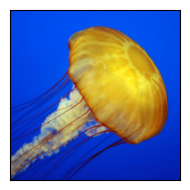

In [ ]:
plt.figure(figsize=(2 * len(imgfiles), 2))

for i, imgfile in enumerate(imgfiles):
    plt.subplot(1, len(imgfiles), i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(np.transpose(imgs_no_norm[i].numpy(),
                        [1, 2, 0]),
           interpolation=None)
    

plt.tight_layout() 

In [ ]:
resnet_model.eval()

#apply resnet to image with no training involved because weights are already determined 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
img_preds = resnet_model(imgs)

In [28]:
# apply softmax to the outputs of the ResNet
img_probs = np.exp(np.asarray(img_preds.detach()))
img_probs /= img_probs.sum(1)[:,None]


NameError: name 'img_preds' is not defined

In [27]:
img_probs

NameError: name 'img_probs' is not defined

In [ ]:
labels = ResNet50_Weights.DEFAULT.meta["categories"]

class_labels = pd.DataFrame({
    "idx": range(len(labels)),
    "label": labels
}).set_index("idx")
class_labels

#only take categories with the highest categories 

,label
idx,
0,tench
1,goldfish
2,great white shark
3,tiger shark
4,hammerhead
...,...
995,earthstar
996,hen-of-the-woods
997,bolete


In [ ]:
for i, imgfile in enumerate(imgfiles):
    img_df = class_labels.copy()
    img_df['prob'] = img_probs[i]
    img_df = img_df.sort_values(by='prob', ascending=False)[:3]
    print(f'Image: {imgfile}')
    print(img_df.reset_index().drop(columns=['idx']))

    # only categories with prediction probabilities greater than 0.01

Image: img_examples/Jelly_cc11.jpg
       label      prob
0  jellyfish  0.335069
1   mushroom  0.001836
2     orange  0.001595
